<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº6
#### Nicolás Galván

# Introducción

Los filtros digitales constituyen una herramienta fundamental en el procesamiento digital de señales, ya que permiten modificar selectivamente el contenido espectral de una señal mediante operaciones matemáticas implementadas sobre secuencias discretas. Entre ellos, los filtros FIR (*Finite Impulse Response*) se destacan por su estabilidad inherente y por la posibilidad de diseñar respuestas de fase lineal, propiedad que evita la distorsión temporal de las componentes frecuenciales de la señal procesada.

En este trabajo práctico se analizan distintos sistemas discretos definidos por ecuaciones en diferencias, obteniendo sus correspondientes funciones de transferencia mediante la Transformada Z. A partir de estas expresiones se estudia la ubicación de polos y ceros en el plano complejo, permitiendo relacionar dichas características con el comportamiento espectral de cada filtro.

Posteriormente, se determina la respuesta en frecuencia de los sistemas, analizando su módulo, fase y retardo de grupo. El estudio de estas magnitudes permite identificar el tipo de filtrado realizado por cada estructura, distinguiendo comportamientos pasa-bajos, pasa-altos y pasa-banda. Asimismo, se verifica la propiedad de fase lineal mediante el análisis del retardo de grupo, así como la clasificación de los filtros FIR en los tipos I, II, III y IV según la simetría de su respuesta impulsiva.

Finalmente, los resultados teóricos son contrastados con simulaciones realizadas en Python utilizando herramientas de análisis de sistemas digitales. Esta comparación permite validar las expresiones obtenidas analíticamente y comprender las diferencias que pueden surgir en la representación numérica de magnitudes como la fase y el retardo de grupo, especialmente en las frecuencias asociadas a los ceros de la función de transferencia.

# Ejercicio Nº1 y Nº2

In [120]:
from IPython.display import IFrame

IFrame("TS6.pdf", width=1000, height=800)

In [121]:
from IPython.display import Markdown

Markdown("[Ver PDF](TS6.pdf)")

[Ver PDF](TS6.pdf)

# Ejercicio Nº3

## a)

Llamo a las librerías a utilizar.

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings

Defino el denominador del sistema (1 por ser un filtro FIR)

In [123]:
a0 = [1]

Defino los coeficientes del numerador.

In [124]:
a = [1, 1, 1, 1]

Cálculo la respuesta en frecuencia del filtro.

In [125]:
wa, Ha = signal.freqz(a, a0, worN=2048)

Cálculo el retardo de grupo.

In [126]:
# Advertencia esperable: el retardo de grupo es singular en las frecuencias donde H(ω)=0.
with warnings.catch_warnings(): # Ignorar la advertencia 
    warnings.simplefilter("ignore")
    wa_gd, gd_a = signal.group_delay((a, a0), w=2048)

Cálculo los ceros.

In [127]:
zeros_a = np.roots(a)

Cálculo los polos.

In [128]:
n_poles_a = len(a) - 1  # polos en z=0

Gráfico el módulo, la fase, el retardo de grupo y el plano z con la circunferencia unitaria y con sus respectivos polos y ceros.

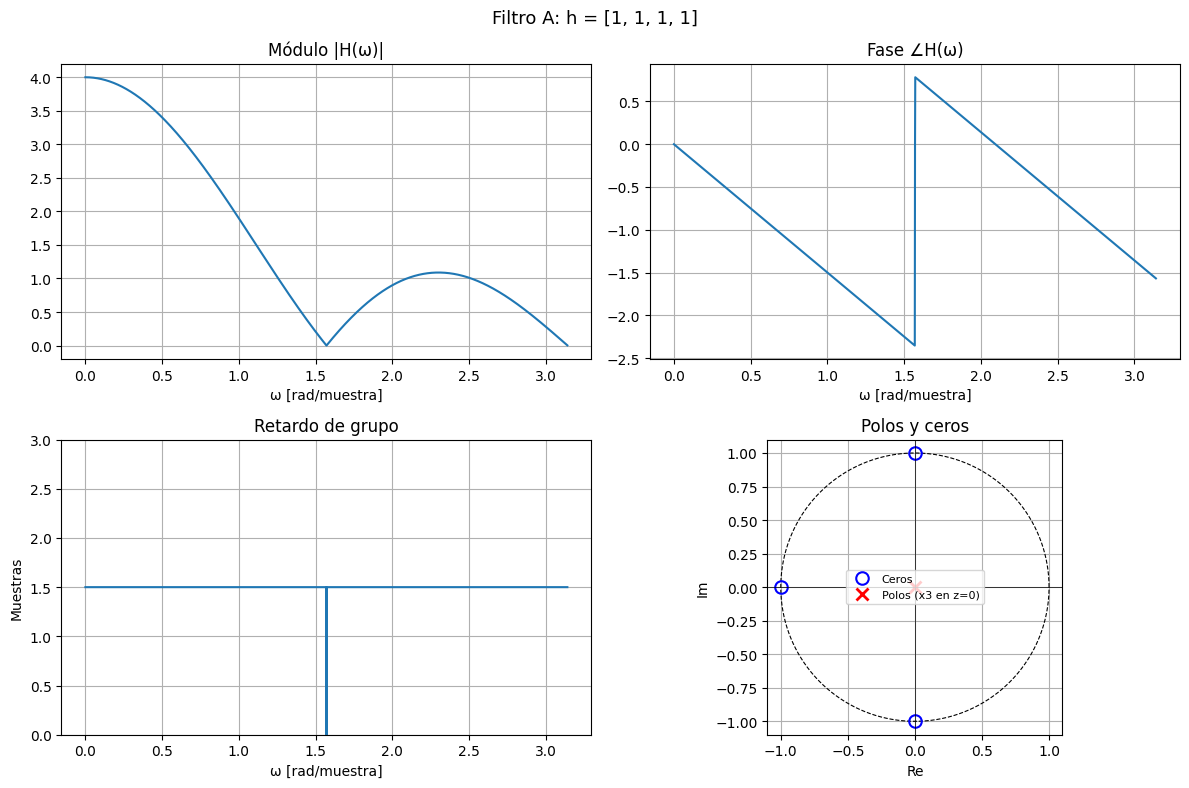

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Filtro A: h = [1, 1, 1, 1]', fontsize=13)

axes[0, 0].plot(wa, np.abs(Ha))
axes[0, 0].set_title('Módulo |H(ω)|')
axes[0, 0].set_xlabel('ω [rad/muestra]')
axes[0, 0].grid()

axes[0, 1].plot(wa, np.angle(Ha))
axes[0, 1].set_title('Fase ∠H(ω)')
axes[0, 1].set_xlabel('ω [rad/muestra]')
axes[0, 1].grid()

axes[1, 0].plot(wa_gd, gd_a)
axes[1,0].set_ylim(0,3)     
axes[1, 0].set_title('Retardo de grupo')
axes[1, 0].set_xlabel('ω [rad/muestra]')
axes[1, 0].set_ylabel('Muestras')
axes[1, 0].grid()

ax = axes[1, 1]
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8)
ax.plot(zeros_a.real, zeros_a.imag, 'o', markersize=9,
        markerfacecolor='none', markeredgecolor='blue', markeredgewidth=1.5, label='Ceros')
ax.plot(0, 0, 'x', markersize=9, color='red', markeredgewidth=2,
        label=f'Polos (x{n_poles_a} en z=0)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_title('Polos y ceros')
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid()
plt.tight_layout()
plt.show()

## b)

Se realizo el mismo procedimiento mencionado en el a pero para el sistema del b.

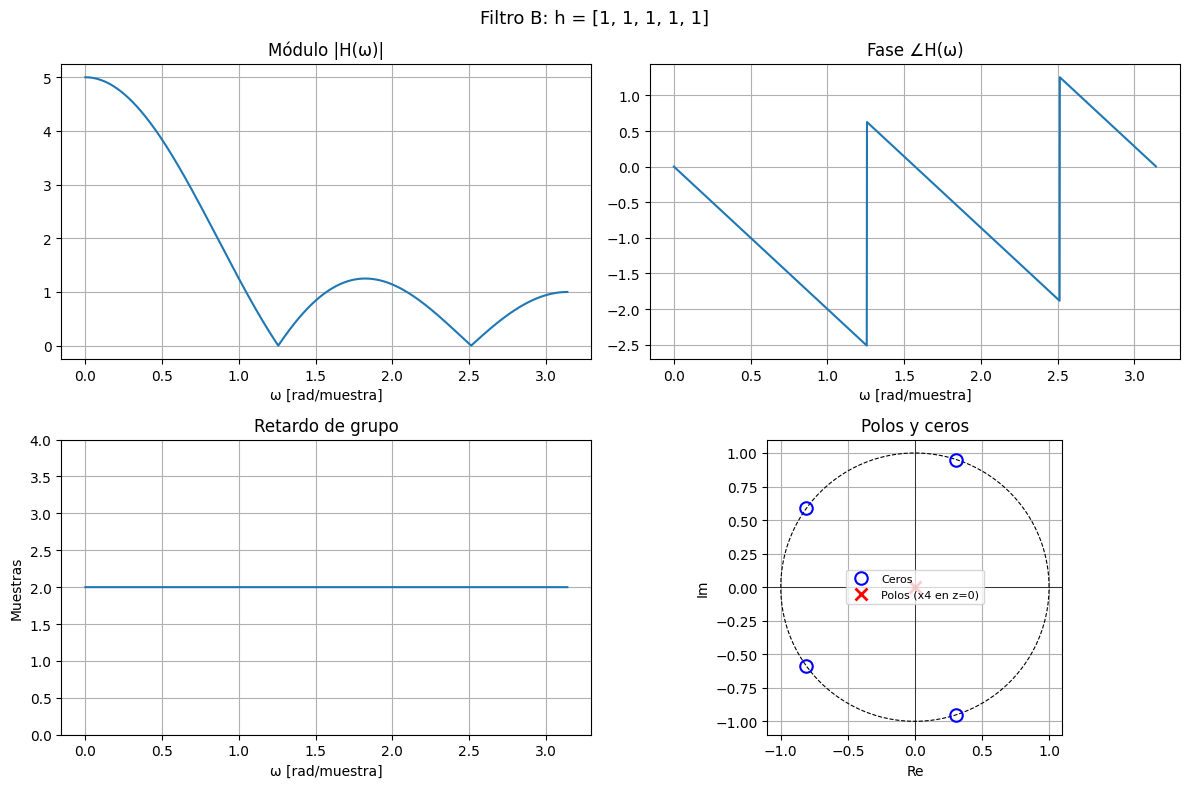

In [130]:
b = [1, 1, 1, 1, 1]
wb, Hb = signal.freqz(b, a0, worN=2048)

# Advertencia esperable: el retardo de grupo es singular en las frecuencias donde H(ω)=0.
with warnings.catch_warnings(): # Ignorar la advertencia
    warnings.simplefilter("ignore")
    wb_gd, gd_b = signal.group_delay((b, a0), w=2048)

zeros_b = np.roots(b)
n_poles_b = len(b) - 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Filtro B: h = [1, 1, 1, 1, 1]', fontsize=13)

axes[0, 0].plot(wb, np.abs(Hb))
axes[0, 0].set_title('Módulo |H(ω)|')
axes[0, 0].set_xlabel('ω [rad/muestra]')
axes[0, 0].grid()

axes[0, 1].plot(wb, np.angle(Hb))
axes[0, 1].set_title('Fase ∠H(ω)')
axes[0, 1].set_xlabel('ω [rad/muestra]')
axes[0, 1].grid()

axes[1, 0].plot(wb_gd, gd_b)
axes[1,0].set_ylim(0,4)      
axes[1, 0].set_title('Retardo de grupo')
axes[1, 0].set_xlabel('ω [rad/muestra]')
axes[1, 0].set_ylabel('Muestras')
axes[1, 0].grid()

ax = axes[1, 1]
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8)
ax.plot(zeros_b.real, zeros_b.imag, 'o', markersize=9,
        markerfacecolor='none', markeredgecolor='blue', markeredgewidth=1.5, label='Ceros')
ax.plot(0, 0, 'x', markersize=9, color='red', markeredgewidth=2,
        label=f'Polos (x{n_poles_b} en z=0)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_title('Polos y ceros')
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid()
plt.tight_layout()
plt.show()

## c)

Se realizo el mismo procedimiento mencionado en el a pero para el sistema del c.

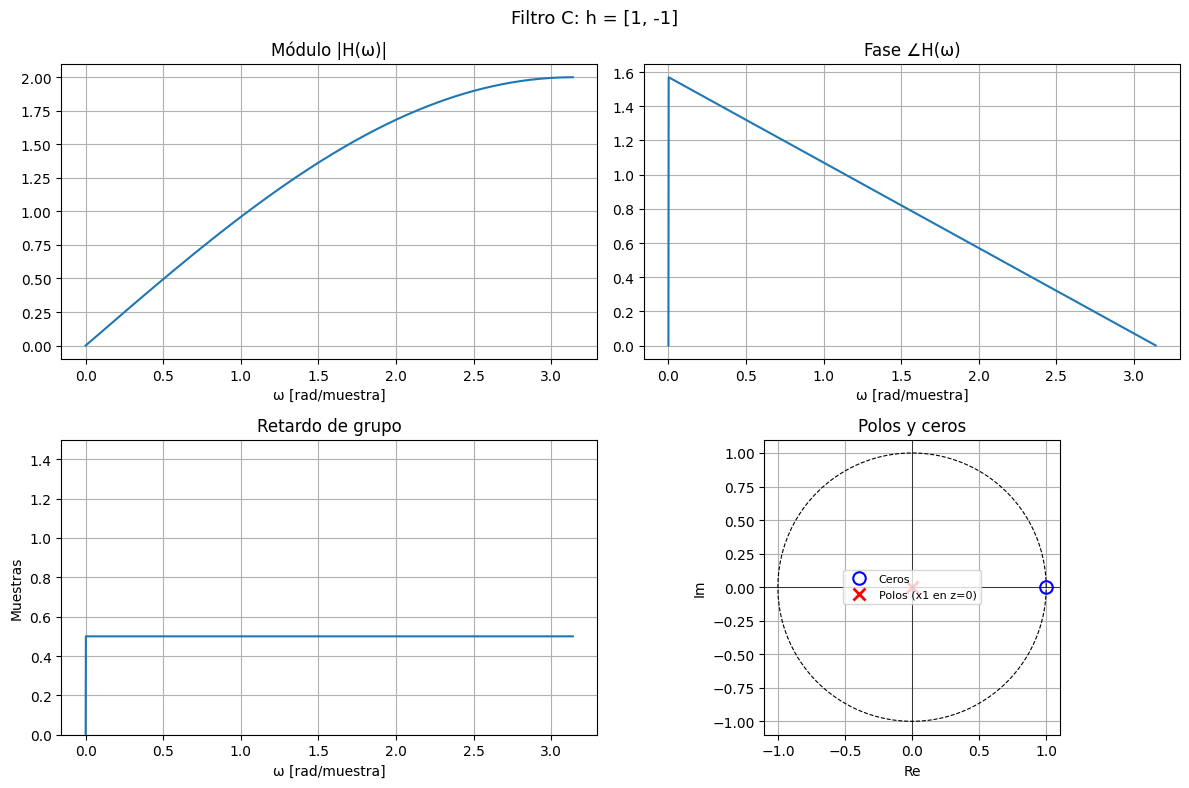

In [131]:
c = [1, -1]
wc, Hc = signal.freqz(c, a0, worN=2048)

# Advertencia esperable: el retardo de grupo es singular en las frecuencias donde H(ω)=0.
with warnings.catch_warnings(): # Ignorar la advertencia
    warnings.simplefilter("ignore")
    wc_gd, gd_c = signal.group_delay((c, a0), w=2048)
zeros_c = np.roots(c)
n_poles_c = len(c) - 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Filtro C: h = [1, -1]', fontsize=13)

axes[0, 0].plot(wc, np.abs(Hc))
axes[0, 0].set_title('Módulo |H(ω)|')
axes[0, 0].set_xlabel('ω [rad/muestra]')
axes[0, 0].grid()

axes[0, 1].plot(wc, np.angle(Hc))
axes[0, 1].set_title('Fase ∠H(ω)')
axes[0, 1].set_xlabel('ω [rad/muestra]')
axes[0, 1].grid()

axes[1, 0].plot(wc_gd, gd_c)
axes[1,0].set_ylim(0,1.5)    # C
axes[1, 0].set_title('Retardo de grupo')
axes[1, 0].set_xlabel('ω [rad/muestra]')
axes[1, 0].set_ylabel('Muestras')
axes[1, 0].grid()

ax = axes[1, 1]
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8)
ax.plot(zeros_c.real, zeros_c.imag, 'o', markersize=9,
        markerfacecolor='none', markeredgecolor='blue', markeredgewidth=1.5, label='Ceros')
ax.plot(0, 0, 'x', markersize=9, color='red', markeredgewidth=2,
        label=f'Polos (x{n_poles_c} en z=0)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_title('Polos y ceros')
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid()
plt.tight_layout()
plt.show()

## d)

Se realizo el mismo procedimiento mencionado en el a pero para el sistema del d.

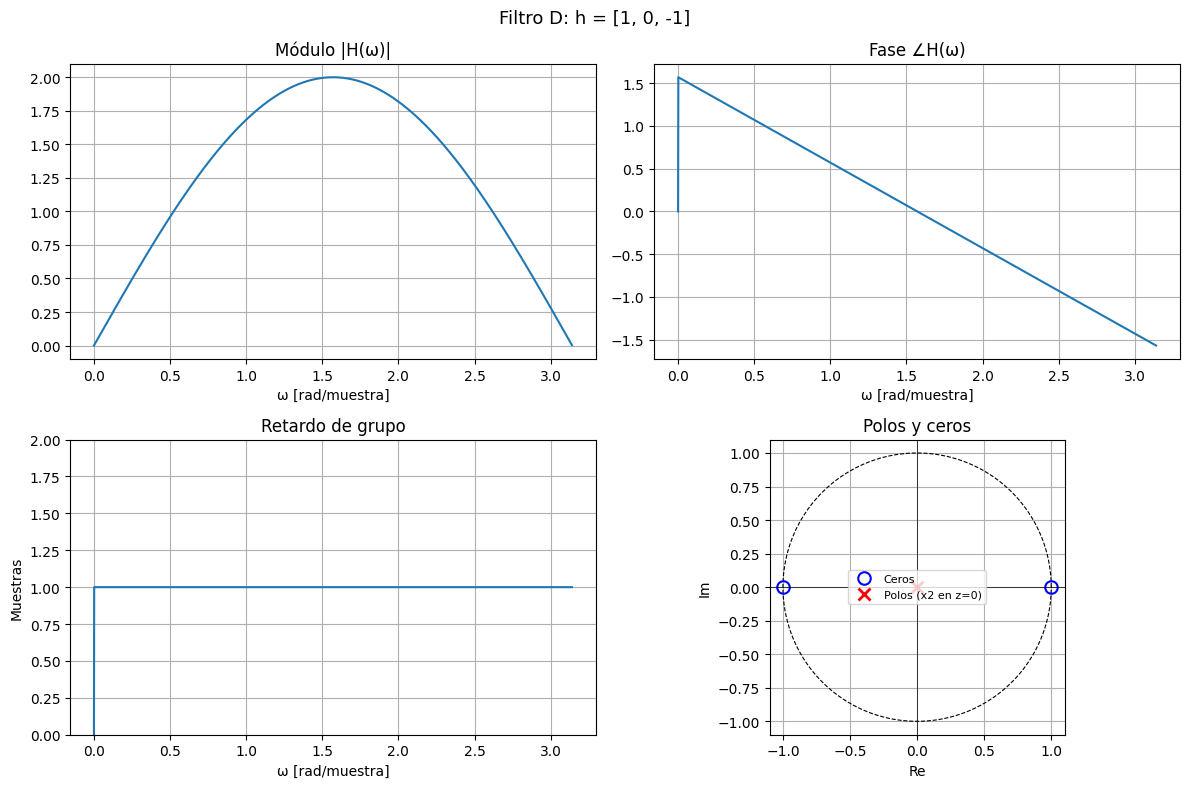

In [132]:
d = [1, 0, -1]
wd, Hd = signal.freqz(d, a0, worN=2048)

# Advertencia esperable: el retardo de grupo es singular en las frecuencias donde H(ω)=0.
with warnings.catch_warnings(): # Ignorar la advertencia
    warnings.simplefilter("ignore")
    wd_gd, gd_d = signal.group_delay((d, a0), w=2048)

zeros_d = np.roots(d)
n_poles_d = len(d) - 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Filtro D: h = [1, 0, -1]', fontsize=13)

axes[0, 0].plot(wd, np.abs(Hd))
axes[0, 0].set_title('Módulo |H(ω)|')
axes[0, 0].set_xlabel('ω [rad/muestra]')
axes[0, 0].grid()

axes[0, 1].plot(wd, np.angle(Hd))
axes[0, 1].set_title('Fase ∠H(ω)')
axes[0, 1].set_xlabel('ω [rad/muestra]')
axes[0, 1].grid()

axes[1, 0].plot(wd_gd, gd_d)
axes[1,0].set_ylim(0,2) 
axes[1, 0].set_title('Retardo de grupo')
axes[1, 0].set_xlabel('ω [rad/muestra]')
axes[1, 0].set_ylabel('Muestras')
axes[1, 0].grid()

ax = axes[1, 1]
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.8)
ax.plot(zeros_d.real, zeros_d.imag, 'o', markersize=9,
        markerfacecolor='none', markeredgecolor='blue', markeredgewidth=1.5, label='Ceros')
ax.plot(0, 0, 'x', markersize=9, color='red', markeredgewidth=2,
        label=f'Polos (x{n_poles_d} en z=0)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_title('Polos y ceros')
ax.set_xlabel('Re')
ax.set_ylabel('Im')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid()
plt.tight_layout()

plt.show()

# Observaciones

## Comparación del módulo

Para los cuatro sistemas analizados, el módulo calculado analíticamente coincide con el obtenido mediante simulación:

### Filtro A
- Presenta un máximo de valor 4.
- Posee ceros en $\omega = \pi/2$ y $\omega = \pi$, dentro del intervalo $[0, \pi]$.
- Su comportamiento corresponde a un filtro pasa-bajos.

### Filtro B
- Presenta un máximo de valor 5.
- Posee ceros en $\omega = 2\pi/5$ y $\omega = 4\pi/5$, dentro del intervalo $[0, \pi]$.
- Se observa una respuesta pasa-bajos más selectiva que la del filtro A.

### Filtro C
- Presenta un máximo de valor 2.
- Posee un cero en $\omega = 0$, dentro del intervalo $[0, \pi]$.
- Se comporta como un filtro pasa-altos.

### Filtro D
- Presenta un máximo de valor 2.
- Posee un cero en $\omega = 0$ y $\omega = \pi$, dentro del intervalo $[0, \pi]$.
- Su comportamiento corresponde a un filtro pasa-banda.

## Comparación de la fase

La principal diferencia entre los resultados analíticos y los obtenidos por simulación aparece en la representación de la fase.

Analíticamente se obtuvieron expresiones lineales:

- Filtro A:
  
  $$
  \angle H_A(\omega)=-\frac{3}{2}\omega
  $$

- Filtro B:
  
  $$
  \angle H_B(\omega)=-2\omega
  $$

- Filtro C:
  
  $$
  \angle H_C(\omega)=-\frac{\omega}{2}+\frac{\pi}{2}
  $$

- Filtro D:
  
  $$
  \angle H_D(\omega)=-\omega+\frac{\pi}{2}
  $$

Estas expresiones representan la fase ideal o continua, asociada al retardo lineal de cada sistema.

Sin embargo, en los gráficos generados por Python aparecen saltos bruscos de fase de aproximadamente $\pi$ radianes. Esto ocurre porque la función utilizada para calcular la respuesta en frecuencia devuelve la fase principal, restringida al intervalo:

$$
[-\pi,\pi]
$$

Cuando la fase real supera alguno de esos límites, el software realiza automáticamente un cambio de rama, generando discontinuidades visibles en el gráfico.

Por ejemplo:

- En el filtro A el salto aparece en $\omega=\pi/2$.
- En el filtro B se observan varios saltos coincidentes con las frecuencias donde existen ceros de la respuesta.
- En los filtros C y D también aparecen cambios de fase asociados a los ceros ubicados en $\omega= 0$.

Por lo tanto, la diferencia observada no corresponde a un error del análisis teórico ni de la simulación, sino únicamente a la forma en que se representa la fase.

## Retardo de grupo

Los resultados de retardo de grupo verifican el carácter de fase lineal de los sistemas:

- Filtro A:
  
  $$
  M = \frac{3}{2}
  $$

- Filtro B:
  
  $$
  M = 2
  $$

- Filtro C:
  
  $$
  M = \frac{1}{2}
  $$

- Filtro D:
  
  $$
  M = 1
  $$

En las simulaciones estos valores permanecen prácticamente constantes, excepto en las cercanías de los ceros de la respuesta, donde aparecen picos numéricos debido a singularidades en el cálculo de la fase.

## Clasificación de los filtros FIR

A partir de la simetría o antisimetría de sus coeficientes, los sistemas analizados pueden clasificarse dentro de las cuatro categorías clásicas de filtros FIR de fase lineal:

| Filtro | Respuesta impulsiva | Simetría | Longitud \(N\) | Tipo FIR |
|---------|---------|---------|---------|---------|
| A | \([1,1,1,1]\) | Simétrica | Par (4) | Tipo II |
| B | \([1,1,1,1,1]\) | Simétrica | Impar (5) | Tipo I |
| C | \([1,-1]\) | Antisimétrica | Par (2) | Tipo IV |
| D | \([1,0,-1]\) | Antisimétrica | Impar (3) | Tipo III |

Recordando la clasificación general:

- **Tipo I:** respuesta impulsiva simétrica y longitud impar.
- **Tipo II:** respuesta impulsiva simétrica y longitud par.
- **Tipo III:** respuesta impulsiva antisimétrica y longitud impar.
- **Tipo IV:** respuesta impulsiva antisimétrica y longitud par.

Esta clasificación resulta consistente con el comportamiento observado en las respuestas en frecuencia obtenidas analítica y numéricamente. Los filtros A y B, correspondientes a los tipos II y I respectivamente, presentan una respuesta característica de filtros pasa-bajos. Por otro lado, los filtros C y D, pertenecientes a los tipos IV y III, poseen diferentes respuestas a las ya mencionadas, en el caso del filtro C exhibe un comportamiento pasa-altos, mientras que el filtro D presenta características de filtro pasa-banda. Estas observaciones coinciden con la ubicación de los ceros en el plano Z y con las respuestas en frecuencia obtenidas para cada sistema.

# Conclusiones

El análisis realizado permitió obtener las funciones de transferencia mediante la Transformada Z, la ubicación de polos y ceros, y las respuestas en frecuencia de cuatro filtros FIR.

Los resultados obtenidos mediante simulación confirmaron las expresiones deducidas analíticamente para el módulo, la fase y el retardo de grupo. Las pequeñas discrepancias observadas en los gráficos de fase se deben exclusivamente al fenómeno que ocurre al usar las herramientas de simulación para representar la fase dentro del intervalo $[-\pi,\pi]$.

Asimismo, se comprobó que la ubicación de los ceros sobre el círculo unitario determina directamente las frecuencias donde la respuesta se anula, permitiendo interpretar fácilmente el comportamiento de cada filtro. Los filtros A y B presentan características pasa-bajos, mientras que los filtros C y D actúan como pasa-altos y pasa-banda respectivamente.

Finalmente, se verificó que todos los sistemas poseen fase lineal y retardo de grupo constante, propiedad deseable en procesamiento digital de señales debido a que evita la distorsión temporal de las componentes espectrales de la señal procesada.